### Data

In [2]:
# Load the data (Downloaded from 'https://github.com/chrisdonahue/nesmdb#separated-score')

import os
import pickle
import numpy as np

# Train
train_dir = 'nesmdb24_seprsco/train'
train_files = os.listdir(train_dir)

train_data = [] 

for filename in train_files:
    filepath = os.path.join(train_dir, filename)
    with open(filepath, 'rb') as f:
        rate, nsamps, seprsco = pickle.load(f)
    train_data.append(seprsco)

list_lengthhs = []              # Drops songs that are too short or to long to prevent noise and overfitting 
for song in train_data:
    list_lengthhs.append(len(song))
    
arr = np.array(list_lengthhs)
p20 = np.percentile(arr, 20)
p80 = np.percentile(arr, 80)    

train_data = [song for song in train_data if len(song) > p20 and len(song) < p80]

# Valid 
valid_dir = 'nesmdb24_seprsco/valid'
valid_files = os.listdir(valid_dir)

valid_data = [] 

for filename in valid_files:
    filepath = os.path.join(valid_dir, filename)
    with open(filepath, 'rb') as f:
        rate, nsamps, seprsco = pickle.load(f)
    valid_data.append(seprsco)

# Test 
test_dir = 'nesmdb24_seprsco/test'
test_files = os.listdir(test_dir)

test_data = [] 

for filename in test_files:
    filepath = os.path.join(test_dir, filename)
    with open(filepath, 'rb') as f:
        rate, nsamps, seprsco = pickle.load(f)
    test_data.append(seprsco)

In [3]:
# Get values of the music voices, 8-bit music is split into four parts/voices

voice_names = ['p1', 'p2', 'tr', 'no']
voice_data = {}

for column, name in enumerate(voice_names):
    all_values = np.concatenate([song[:, column] for song in train_data])
    value_index = {val: i for i, val in enumerate(np.unique(all_values))}
    
    voice_data[name] = value_index

In [4]:
import torch.nn as nn
import math

# dim = vocab_size ** 0.25 is a commonly used heuristic 

num_embed_p1 = len(voice_data['p1'])
num_embed_p2 = len(voice_data['p2'])
num_embed_tr = len(voice_data['tr'])
num_embed_no = len(voice_data['no'])


embed_dim_p1 = math.ceil(len(voice_data['p1']) ** 0.25) 
embed_dim_p2 = math.ceil(len(voice_data['p2']) ** 0.25) 
embed_dim_tr = math.ceil(len(voice_data['tr']) ** 0.25) 
embed_dim_no = math.ceil(len(voice_data['no']) ** 0.25) 

In [5]:
# Map data to a consistant value space 
import pandas as pd

# Train
train_data_mapped = []

for song in train_data:
    
    remapped_song = np.column_stack([pd.Series(song[:,0]).map(voice_data['p1']),
                                     pd.Series(song[:,1]).map(voice_data['p2']), 
                                     pd.Series(song[:,2]).map(voice_data['tr']), 
                                     pd.Series(song[:,3]).map(voice_data['no'])])
    train_data_mapped.append(remapped_song)

# Valid
valid_data_mapped = []

for song in valid_data:
    
    remapped_song = np.column_stack([pd.Series(song[:,0]).map(voice_data['p1']),
                                     pd.Series(song[:,1]).map(voice_data['p2']), 
                                     pd.Series(song[:,2]).map(voice_data['tr']), 
                                     pd.Series(song[:,3]).map(voice_data['no'])])
    valid_data_mapped.append(remapped_song)

# Test 
test_data_mapped = []

for song in test_data:
    
    remapped_song = np.column_stack([pd.Series(song[:,0]).map(voice_data['p1']),
                                     pd.Series(song[:,1]).map(voice_data['p2']), 
                                     pd.Series(song[:,2]).map(voice_data['tr']), 
                                     pd.Series(song[:,3]).map(voice_data['no'])])
    test_data_mapped.append(remapped_song)

### Model 

In [6]:
import torch

# Slice songs into size 32 notes with size 8 steps (Note: this drops the tail end of song if not divided equally)
windowed_data = []
target_data = []

stride_size = 8 # Hyperparamter set to 8 to capture grainularity in note data without becoming compute constrained by my hardware
window_size = 32 # Hyper parameter set to 32 to have enough previous data to predict next imput in a realistic manner

for song in train_data_mapped:
    n = len(song)
    last_valid_start = n - window_size
    
    for i in range(0, last_valid_start, stride_size):
        window = song[i : i + window_size]
        target = song[i + window_size]
        
        windowed_data.append(window)
        target_data.append(target)

        
windowed_data = np.array(windowed_data)  # Shape is (num_windows, window_size, voices)
target_data = np.array(target_data)      # Shape is (num_windows, voices)

windowed_data = torch.tensor(windowed_data).long()
target_data = torch.tensor(target_data).long()

# Valid
valid_x = []
valid_y = []

for song in valid_data_mapped:
    n = len(song)
    last_valid_start = n - window_size
 
    for i in range(0, last_valid_start, stride_size):
        window = song[i : i + window_size]        
        target = song[i + window_size]           
 
        valid_x.append(window)
        valid_y.append(target)
 
valid_x = np.array(valid_x)  # Shape is (num_windows, window_size, voices)
valid_y = np.array(valid_y)      # Shape is (num_windows, voices)

valid_x = torch.tensor(valid_x).long()
valid_y = torch.tensor(valid_y).long()



# Test 
test_x = []
test_y = []

for song in test_data_mapped:
    n = len(song)
    last_valid_start = n - window_size
 
    for i in range(0, last_valid_start, stride_size):
        window = song[i : i + window_size]        
        target = song[i + window_size]           
 
        test_x.append(window)
        test_y.append(target)
 
test_x = np.array(test_x)  # Shape is (num_windows, window_size, voices)
test_y = np.array(test_y)      # Shape is (num_windows, voices)

test_x = torch.tensor(test_x).long()
test_y = torch.tensor(test_y).long()

In [7]:
class MusicLSTM(nn.Module):
    def __init__(self, 
                 input_size, 
                 hidden_size,  
                 dropout_rate=0.2):
        super().__init__()
        
        # Embed notes so they are vector representations instead of integer values 
        
        self.p1_embedding = nn.Embedding(num_embed_p1, embed_dim_p1)
        self.p2_embedding = nn.Embedding(num_embed_p2, embed_dim_p2)
        self.tr_embedding = nn.Embedding(num_embed_tr, embed_dim_tr)
        self.no_embedding = nn.Embedding(num_embed_no, embed_dim_no)

        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.dropout1 = nn.Dropout(dropout_rate)

        self.lstm2 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.dropout2 = nn.Dropout(dropout_rate)

        self.attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=4, batch_first=True)
        self.norm_attn = nn.LayerNorm(hidden_size)
        
        self.out_p1 = nn.Linear(hidden_size, len(voice_data['p1']))
        self.out_p2 = nn.Linear(hidden_size, len(voice_data['p2']))
        self.out_tr = nn.Linear(hidden_size, len(voice_data['tr']))
        self.out_no = nn.Linear(hidden_size, len(voice_data['no']))

    def forward(self, x):
        
        p1_vectors = self.p1_embedding((x[:, :, 0]))
        p2_vectors = self.p2_embedding((x[:, :, 1]))
        tr_vectors = self.tr_embedding((x[:, :, 2]))
        no_vectors = self.no_embedding((x[:, :, 3]))

        model_input = torch.cat([p1_vectors, p2_vectors, tr_vectors, no_vectors], axis = 2) 
        
        x, _ = self.lstm1(model_input)
        x = self.norm1(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)
        x = self.norm2(x)
        x = self.dropout2(x)

        query = x[:, -1:, :]  
        attn_out, attn_weights = self.attention(query, x, x)  
        x = self.norm_attn(query.squeeze(1) + attn_out.squeeze(1))

        pred_p1 = self.out_p1(x)
        pred_p2 = self.out_p2(x)
        pred_tr = self.out_tr(x)
        pred_no = self.out_no(x)

        return pred_p1, pred_p2, pred_tr, pred_no

In [8]:
size_input = sum([embed_dim_p1, embed_dim_p2, embed_dim_tr, embed_dim_no])

model = MusicLSTM(
    input_size = size_input,
    hidden_size = size_input * 4,
)

In [9]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=.00001)

dataset = TensorDataset(windowed_data, target_data)
data_loader = DataLoader(dataset, batch_size = 64, shuffle = True)

dataset_valid = TensorDataset(valid_x, valid_y)
data_loader_valid = DataLoader(dataset_valid, batch_size = 64, shuffle = False)

dataset_test = TensorDataset(test_x, test_y)
data_loader_test = DataLoader(dataset_test, batch_size = 64, shuffle = False) 

graph_train_loss = []
graph_valid_loss = []

num_epochs = 16 # Results suggest continuing to increase epochs, however, hardware constraint/runtime is limiting factor

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    p1 = p2 = tr = no = 0

    for inputs, labels in data_loader: 
        optimizer.zero_grad()
        predictions = model(inputs)
        
        loss_p1 = criterion(predictions[0], labels[:, 0])
        loss_p2 = criterion(predictions[1], labels[:, 1])
        loss_tr = criterion(predictions[2], labels[:, 2])
        loss_no = criterion(predictions[3], labels[:, 3])
        
        total_loss = loss_p1 + loss_p2 + loss_tr + loss_no
        
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()
        p1 += loss_p1.item()
        p2 += loss_p2.item()
        tr += loss_tr.item()
        no += loss_no.item()
        

    avg_loss = epoch_loss / len(data_loader)
    avg_loss_p1 = p1 / len(data_loader)
    avg_loss_p2 = p2 / len(data_loader)
    avg_loss_tr = tr / len(data_loader)
    avg_loss_no = no / len(data_loader)

    graph_train_loss.append(avg_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for inputs, labels in data_loader_valid: 
            predictions = model(inputs)
        
            loss_p1 = criterion(predictions[0], labels[:, 0])
            loss_p2 = criterion(predictions[1], labels[:, 1])
            loss_tr = criterion(predictions[2], labels[:, 2])
            loss_no = criterion(predictions[3], labels[:, 3])
        
            total_loss_val = loss_p1 + loss_p2 + loss_tr + loss_no
            val_loss += total_loss_val.item()

    avg_loss_val = val_loss / len(data_loader_valid)

    graph_valid_loss.append(avg_loss_val)
    
    print(f'Epoch {epoch + 1}: Train average loss {avg_loss:.4f}, Validation average loss {avg_loss_val:.4f}')
    print(f' p1 loss: {avg_loss_p1:.4f}, p2 loss: {avg_loss_p2:.4f}, tr loss: {avg_loss_tr:.4f}, no loss: {avg_loss_no:.4f}')

Epoch 1: Train average loss 11.3260, Validation average loss 9.9881
 p1 loss: 3.4200, p2 loss: 3.3504, tr loss: 3.0305, no loss: 1.5252
Epoch 2: Train average loss 9.1820, Validation average loss 8.5540
 p1 loss: 2.7668, p2 loss: 2.7064, tr loss: 2.4095, no loss: 1.2994
Epoch 3: Train average loss 8.1623, Validation average loss 7.7876
 p1 loss: 2.4207, p2 loss: 2.4079, tr loss: 2.1138, no loss: 1.2200
Epoch 4: Train average loss 7.5371, Validation average loss 7.2549
 p1 loss: 2.2013, p2 loss: 2.2078, tr loss: 1.9527, no loss: 1.1752
Epoch 5: Train average loss 7.0868, Validation average loss 6.8311
 p1 loss: 2.0441, p2 loss: 2.0481, tr loss: 1.8475, no loss: 1.1471
Epoch 6: Train average loss 6.7350, Validation average loss 6.4891
 p1 loss: 1.9292, p2 loss: 1.9096, tr loss: 1.7685, no loss: 1.1276
Epoch 7: Train average loss 6.4460, Validation average loss 6.1976
 p1 loss: 1.8334, p2 loss: 1.7963, tr loss: 1.7043, no loss: 1.1120
Epoch 8: Train average loss 6.2161, Validation average

In [10]:
# Log of vocabulary size is standard baseline for measuring loss (it represents what the loss would be using a random guess)
print('Voice loss condition')
print('p1 condition passed') if avg_loss_p1 < np.log(num_embed_p1) else  print('p1 condition failed')
print('p2 condition passed') if avg_loss_p2 < np.log(num_embed_p2) else  print('p2 condition failed')
print('tr condition passed') if avg_loss_tr < np.log(num_embed_tr) else  print('tr condition failed')
print('no condition passed') if avg_loss_no < np.log(num_embed_no) else  print('no condition failed')


Voice loss condition
p1 condition passed
p2 condition passed
tr condition passed
no condition passed


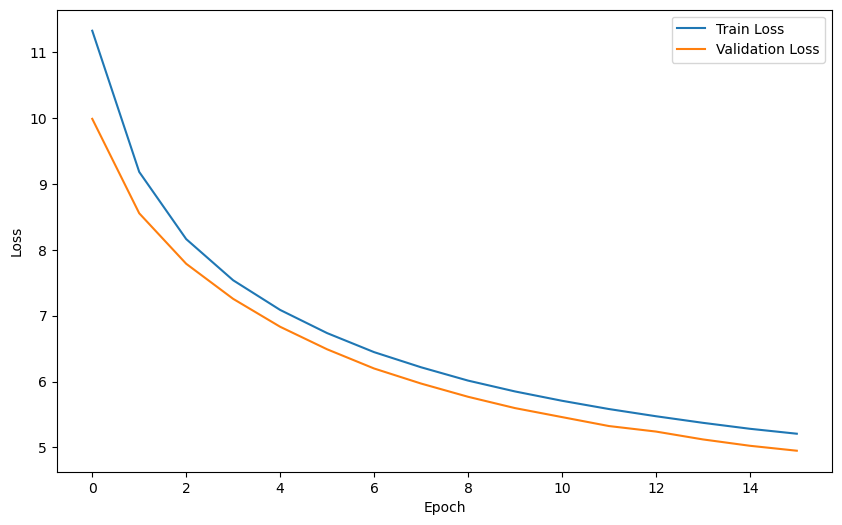

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(graph_train_loss, label='Train Loss') 
plt.plot(graph_valid_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
model.eval()
test_loss = 0
p1_test = p2_test = tr_test = no_test = 0

with torch.no_grad():
    for inputs, labels in data_loader_test:
        predictions = model(inputs)

        loss_p1 = criterion(predictions[0], labels[:, 0])
        loss_p2 = criterion(predictions[1], labels[:, 1])
        loss_tr = criterion(predictions[2], labels[:, 2])
        loss_no = criterion(predictions[3], labels[:, 3])

        total_loss_test = loss_p1 + loss_p2 + loss_tr + loss_no
        test_loss += total_loss_test.item()
        p1_test += loss_p1.item()
        p2_test += loss_p2.item()
        tr_test += loss_tr.item()
        no_test += loss_no.item()

avg_loss_test = test_loss / len(data_loader_test)
avg_p1_test = p1_test / len(data_loader_test)
avg_p2_test = p2_test / len(data_loader_test)
avg_tr_test = tr_test / len(data_loader_test)
avg_no_test = no_test / len(data_loader_test)

print(f'Test loss: {avg_loss_test:.4f}')
print(f'p1: {avg_p1_test:.4f}, p2: {avg_p2_test:.4f}, tr: {avg_tr_test:.4f}, no: {avg_no_test:.4f}')
print(f'Benchmark loss: {sum([np.log(num_embed_p1),np.log(num_embed_p2),np.log(num_embed_tr),np.log(num_embed_no)]):.4f}')
print(f'p1: {np.log(num_embed_p1):.4f}, p2: {np.log(num_embed_p2):.4f}, tr: {np.log(num_embed_tr):.4f}, no: {np.log(num_embed_no):.4f}')

Test loss: 4.4766
p1: 1.2849, p2: 1.2776, tr: 0.9590, no: 0.9551
Benchmark loss: 16.0095
p1: 4.3438, p2: 4.3438, tr: 4.4886, no: 2.8332


In [13]:
torch.save(model.state_dict(), 'best_model.pt')